# Olist Brazilian E-Commerce — Exploratory Data Analysis

This notebook walks through the nine CSV files that make up the Olist dataset (orders placed on Brazilian marketplaces between 2016 and 2018).

**Structure**

1. Setup & loading
2. Dataset overview (shape, memory, missing values, duplicates)
3. Table-by-table EDA
   - Orders · Order items · Products · Customers · Sellers · Payments · Reviews · Geolocation · Category translation
4. How the tables link together (referential integrity)
5. Cross-table analysis (revenue, delivery performance vs. reviews, geography)
6. Key takeaways

**Data model**

```
customers ──┐
            ├── orders ──┬── order_items ──┬── products ── category_translation
geolocation ┘            │                 └── sellers ── geolocation
                         ├── order_payments
                         └── order_reviews
```


## 1. Setup & loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = "data/"


In [5]:
files = {
    "orders":       "olist_orders_dataset.csv",
    "order_items":  "olist_order_items_dataset.csv",
    "products":     "olist_products_dataset.csv",
    "customers":    "olist_customers_dataset.csv",
    "sellers":      "olist_sellers_dataset.csv",
    "payments":     "olist_order_payments_dataset.csv",
    "reviews":      "olist_order_reviews_dataset.csv",
    "geolocation":  "olist_geolocation_dataset.csv",
    "category_tr":  "product_category_name_translation.csv",
}

dfs = {name: pd.read_csv(DATA_DIR + fname) for name, fname in files.items()}

# parse datetimes
date_cols = {
    "orders": ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
               "order_delivered_customer_date", "order_estimated_delivery_date"],
    "order_items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}
for name, cols in date_cols.items():
    for c in cols:
        dfs[name][c] = pd.to_datetime(dfs[name][c])

# short aliases
orders, items, products, customers, sellers, payments, reviews, geo, cat_tr = (
    dfs["orders"], dfs["order_items"], dfs["products"], dfs["customers"], dfs["sellers"],
    dfs["payments"], dfs["reviews"], dfs["geolocation"], dfs["category_tr"])

print("Loaded", len(dfs), "tables")


Loaded 9 tables


In [6]:
dfs

{'orders':                                order_id                       customer_id order_status order_purchase_timestamp   order_approved_at  \
 0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
 1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
 2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
 3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
 4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   
 ...                                 ...                               ...          ...                      ...                 ...   
 99436  9c5dedf39a927c1b2549525ed64a05

## 2. Dataset overview

In [7]:
summary = pd.DataFrame({
    "rows": {k: len(v) for k, v in dfs.items()},
    "columns": {k: v.shape[1] for k, v in dfs.items()},
    "memory_MB": {k: v.memory_usage(deep=True).sum() / 1e6 for k, v in dfs.items()},
    "duplicate_rows": {k: v.duplicated().sum() for k, v in dfs.items()},
    "cells_missing_%": {k: 100 * v.isna().sum().sum() / v.size for k, v in dfs.items()},
})
summary["memory_MB"] = summary["memory_MB"].round(1)
summary["cells_missing_%"] = summary["cells_missing_%"].round(2)
summary

,rows,columns,memory_MB,duplicate_rows,cells_missing_%
orders,99441,8,25.90,0,0.62
order_items,112650,7,31.00,0,0.00
products,32951,9,6.60,0,0.83
customers,99441,5,27.90,0,0.00
sellers,3095,4,0.60,0,0.00
payments,103886,5,17.00,0,0.00
reviews,99224,7,29.10,0,21.01
geolocation,1000163,5,135.70,261831,0.00
category_tr,71,2,0.00,0,0.00


In [8]:
def overview(df, name, n=3):
    """Compact profile of one table: dtypes, nulls, cardinality, sample."""
    print(f"=== {name}: {df.shape[0]:,} rows x {df.shape[1]} cols ===")
    prof = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "null_%": (100 * df.isna().mean()).round(2),
        "n_unique": df.nunique(),
        "example": df.iloc[0],
    })
    display(prof)
    display(df.head(n))


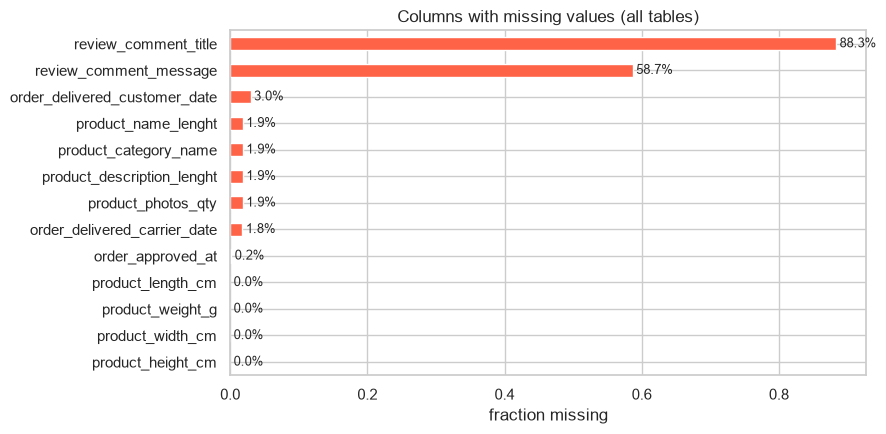

In [9]:
# Missing values across all tables in one view
miss = pd.concat(
    [dfs[k].isna().mean().rename(k) for k in dfs]
).rename("null_frac")
miss = miss[miss > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
miss.plot.barh(ax=ax, color="tomato")
ax.set_xlabel("fraction missing")
ax.set_title("Columns with missing values (all tables)")
ax.invert_yaxis()
for i, v in enumerate(miss):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


**Observations**

- Only a handful of columns have nulls. Review comment titles/messages are mostly empty (customers rarely write text), and the delivery timestamps in `orders` are null for orders that never reached that stage (cancelled, still shipping, etc.).
- `geolocation` is the only table with fully duplicated rows — it contains one row per raw coordinate observation, not one row per zip code.


## 3. Table-by-table EDA

### 3.1 Orders

In [10]:
overview(orders, 'orders')

=== orders: 99,441 rows x 8 cols ===


,dtype,non_null,null_%,n_unique,example
order_id,str,99441,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7
customer_id,str,99441,0.00,99441,9ef432eb6251297304e76186b10a928d
order_status,str,99441,0.00,8,delivered
order_purchase_timestamp,datetime64[us],99441,0.00,98875,2017-10-02 10:56:33
order_approved_at,datetime64[us],99281,0.16,90733,2017-10-02 11:07:15
order_delivered_carrier_date,datetime64[us],97658,1.79,81018,2017-10-04 19:55:00
order_delivered_customer_date,datetime64[us],96476,2.98,95664,2017-10-10 21:25:13
order_estimated_delivery_date,datetime64[us],99441,0.00,459,2017-10-18 00:00:00


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


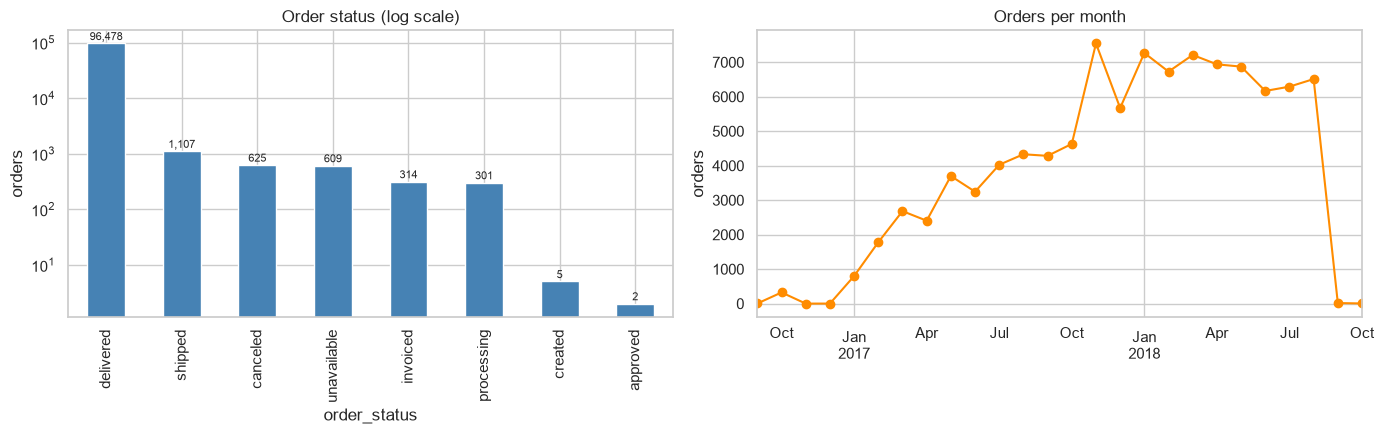

Date range: 2016-09-04 21:15:19  ->  2018-10-17 17:30:18
Delivered share: 97.0%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

status = orders["order_status"].value_counts()
status.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("Order status (log scale)")
axes[0].set_ylabel("orders")
for i, v in enumerate(status):
    axes[0].text(i, v * 1.15, f"{v:,}", ha="center", fontsize=8)

monthly = orders.set_index("order_purchase_timestamp").resample("ME").size()
monthly.plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Orders per month")
axes[1].set_ylabel("orders"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

print(f"Date range: {orders.order_purchase_timestamp.min()}  ->  {orders.order_purchase_timestamp.max()}")
print(f"Delivered share: {status['delivered'] / status.sum():.1%}")


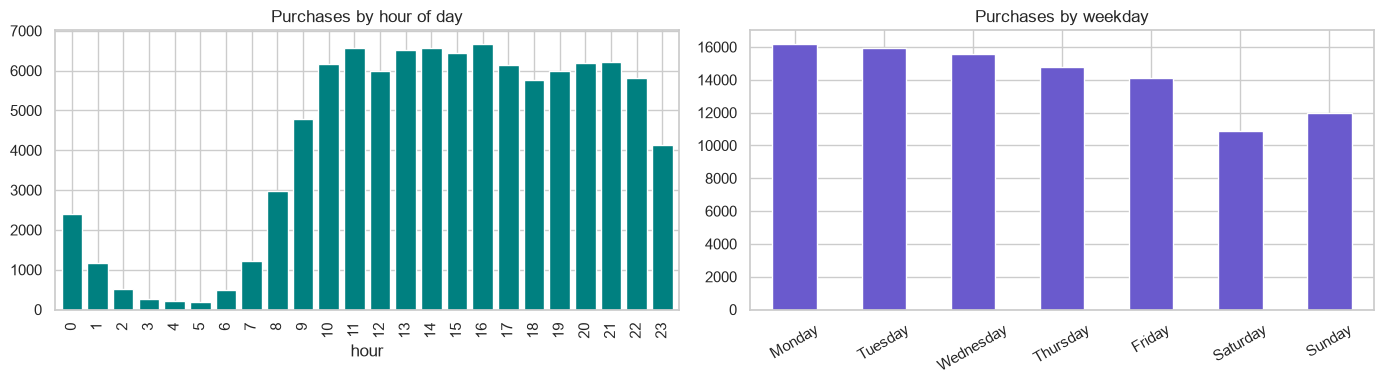

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ts = orders["order_purchase_timestamp"]

ts.dt.hour.value_counts().sort_index().plot.bar(ax=axes[0], color="teal", width=0.8)
axes[0].set_title("Purchases by hour of day"); axes[0].set_xlabel("hour")

dow = ts.dt.day_name().value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
dow.plot.bar(ax=axes[1], color="slateblue")
axes[1].set_title("Purchases by weekday"); axes[1].set_xlabel("")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


#### Delivery performance

                   count   mean   std     min    25%    50%   75%    max
delivery_days  96,470.00  12.09  9.55    0.00   6.00  10.00 15.00 209.00
estimated_days 96,478.00  23.37  8.76    2.00  18.00  23.00 28.00 155.00
delay_days     96,470.00 -11.88 10.18 -147.00 -17.00 -12.00 -7.00 188.00

Late deliveries: 6.8% of delivered orders


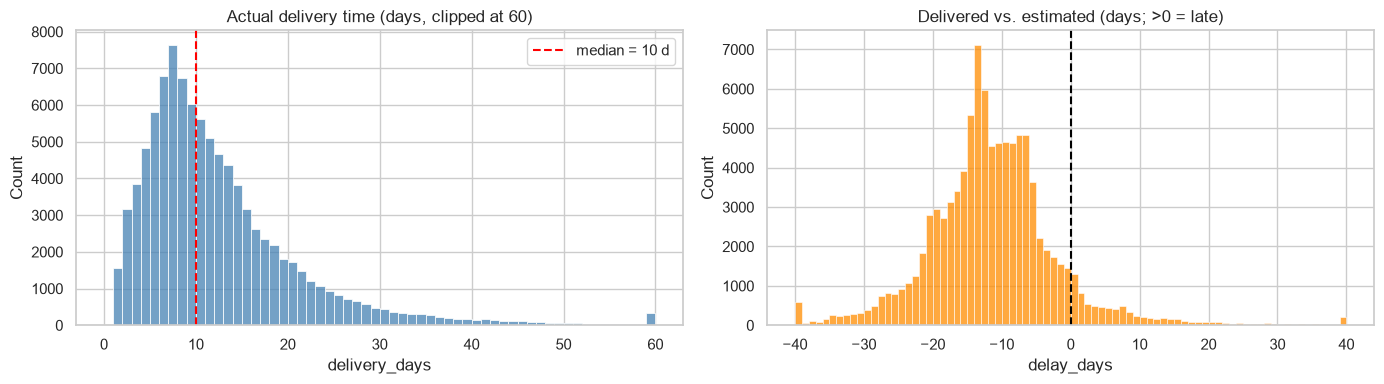

In [13]:
delivered = orders[orders.order_status == "delivered"].copy()
delivered["delivery_days"]  = (delivered.order_delivered_customer_date - delivered.order_purchase_timestamp).dt.days
delivered["estimated_days"] = (delivered.order_estimated_delivery_date - delivered.order_purchase_timestamp).dt.days
delivered["delay_days"]     = (delivered.order_delivered_customer_date - delivered.order_estimated_delivery_date).dt.days
delivered["is_late"]        = delivered["delay_days"] > 0

print(delivered[["delivery_days", "estimated_days", "delay_days"]].describe().T)
print(f"\nLate deliveries: {delivered.is_late.mean():.1%} of delivered orders")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(delivered.delivery_days.clip(upper=60), bins=60, ax=axes[0], color="steelblue")
axes[0].axvline(delivered.delivery_days.median(), color="red", ls="--", label=f"median = {delivered.delivery_days.median():.0f} d")
axes[0].set_title("Actual delivery time (days, clipped at 60)"); axes[0].legend()

sns.histplot(delivered.delay_days.clip(-40, 40), bins=80, ax=axes[1], color="darkorange")
axes[1].axvline(0, color="black", ls="--")
axes[1].set_title("Delivered vs. estimated (days; >0 = late)")
plt.tight_layout(); plt.show()


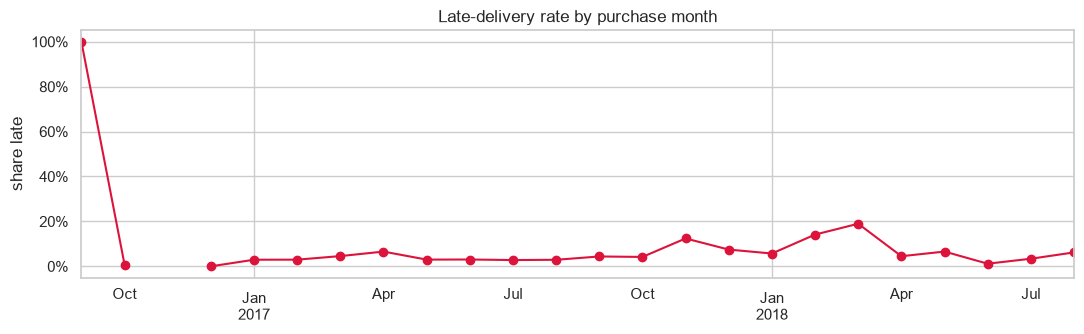

In [14]:
# Late-delivery rate over time
late_m = delivered.set_index("order_purchase_timestamp").resample("ME")["is_late"].mean()
fig, ax = plt.subplots(figsize=(11, 3.5))
late_m.plot(ax=ax, marker="o", color="crimson")
ax.set_ylabel("share late"); ax.set_xlabel("")
ax.set_title("Late-delivery rate by purchase month")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout(); plt.show()


### 3.2 Order items

In [15]:
overview(items, 'order_items')

=== order_items: 112,650 rows x 7 cols ===


,dtype,non_null,null_%,n_unique,example
order_id,str,112650,0.00,98666,00010242fe8c5a6d1ba2dd792cb16214
order_item_id,int64,112650,0.00,21,1
product_id,str,112650,0.00,32951,4244733e06e7ecb4970a6e2683c13e61
seller_id,str,112650,0.00,3095,48436dade18ac8b2bce089ec2a041202
shipping_limit_date,datetime64[us],112650,0.00,93318,2017-09-19 09:45:35
price,float64,112650,0.00,5968,58.90
freight_value,float64,112650,0.00,6999,13.29


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


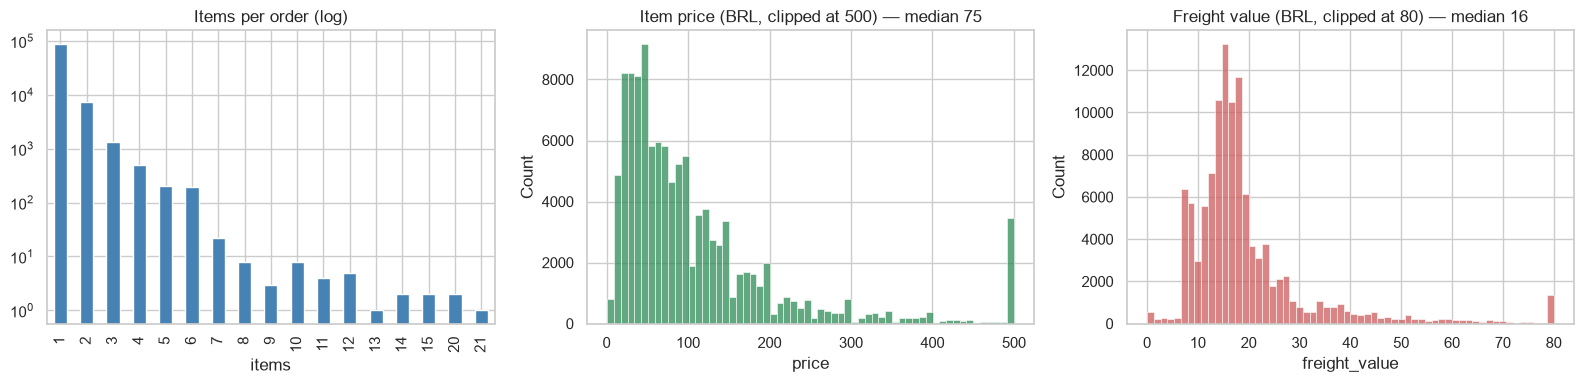

                   count   mean    std  min   25%   50%    75%      max
price         112,650.00 120.65 183.63 0.85 39.90 74.99 134.90 6,735.00
freight_value 112,650.00  19.99  15.81 0.00 13.08 16.26  21.15   409.68

Single-item orders: 90.1%
Freight as share of price (median): 23.1%


In [16]:
items_per_order = items.groupby("order_id")["order_item_id"].max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
items_per_order.value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_yscale("log"); axes[0].set_title("Items per order (log)"); axes[0].set_xlabel("items")

sns.histplot(items.price.clip(upper=500), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title(f"Item price (BRL, clipped at 500) — median {items.price.median():.0f}")

sns.histplot(items.freight_value.clip(upper=80), bins=60, ax=axes[2], color="indianred")
axes[2].set_title(f"Freight value (BRL, clipped at 80) — median {items.freight_value.median():.0f}")
plt.tight_layout(); plt.show()

print(items[["price", "freight_value"]].describe().T)
print(f"\nSingle-item orders: {(items_per_order == 1).mean():.1%}")
print(f"Freight as share of price (median): {(items.freight_value / items.price).median():.1%}")


### 3.3 Products

In [17]:
overview(products, 'products')

=== products: 32,951 rows x 9 cols ===


,dtype,non_null,null_%,n_unique,example
product_id,str,32951,0.00,32951,1e9e8ef04dbcff4541ed26657ea517e5
product_category_name,str,32341,1.85,73,perfumaria
product_name_lenght,float64,32341,1.85,66,40.00
product_description_lenght,float64,32341,1.85,2960,287.00
product_photos_qty,float64,32341,1.85,19,1.00
product_weight_g,float64,32949,0.01,2204,225.00
product_length_cm,float64,32949,0.01,99,16.00
product_height_cm,float64,32949,0.01,102,10.00
product_width_cm,float64,32949,0.01,95,14.00


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00


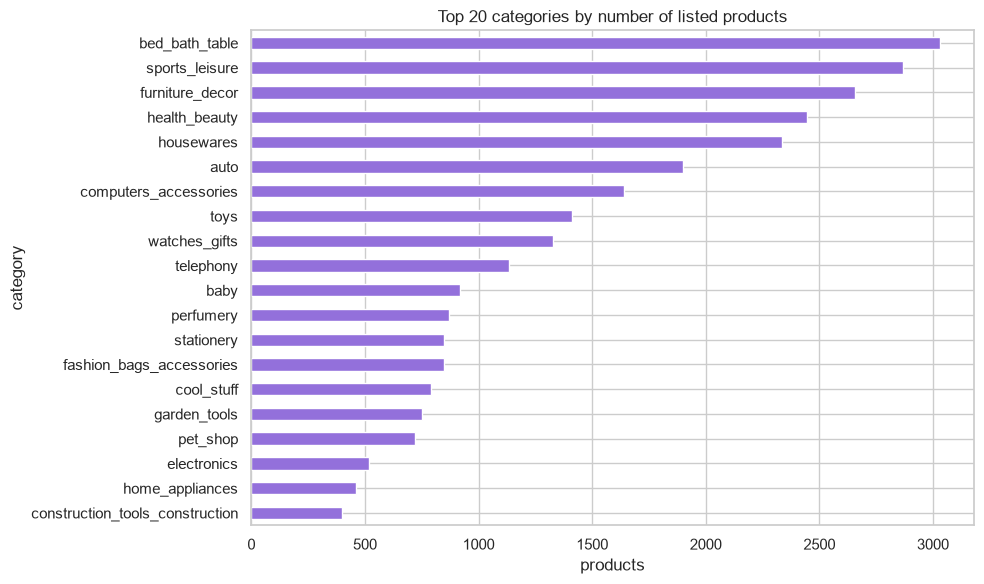

Distinct categories: 73 raw -> 71 after cleaning
Products with no category: 610 (1.9%)
Categories still without an English name: []


In [18]:
products_en = products.merge(cat_tr, on="product_category_name", how="left")

manual_tr = { # missing from raw data
    "pc_gamer": "pc_gamer",
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_preparers",
}
merge_map = {
    "home_confort":      "home_comfort",
    "home_comfort_2":    "home_comfort",
    "home_appliances_2": "home_appliances",
}
products_en["category"] = (products_en["product_category_name_english"]
                           .fillna(products_en["product_category_name"].map(manual_tr))
                           .fillna(products_en["product_category_name"])   # last-resort: keep Portuguese
                           .replace(merge_map))

top_cat = products_en["category"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_cat.plot.barh(ax=ax, color="mediumpurple")
ax.invert_yaxis(); ax.set_title("Top 20 categories by number of listed products"); ax.set_xlabel("products")
plt.tight_layout(); plt.show()

print(f"Distinct categories: {products.product_category_name.nunique()} raw -> {products_en.category.nunique()} after cleaning")
print(f"Products with no category: {products_en.category.isna().sum():,} ({products_en.category.isna().mean():.1%})")
still_pt = set(products_en.category.dropna()) - set(cat_tr.product_category_name_english) - set(manual_tr.values()) - set(merge_map.values())
print("Categories still without an English name:", sorted(still_pt))   # expect []

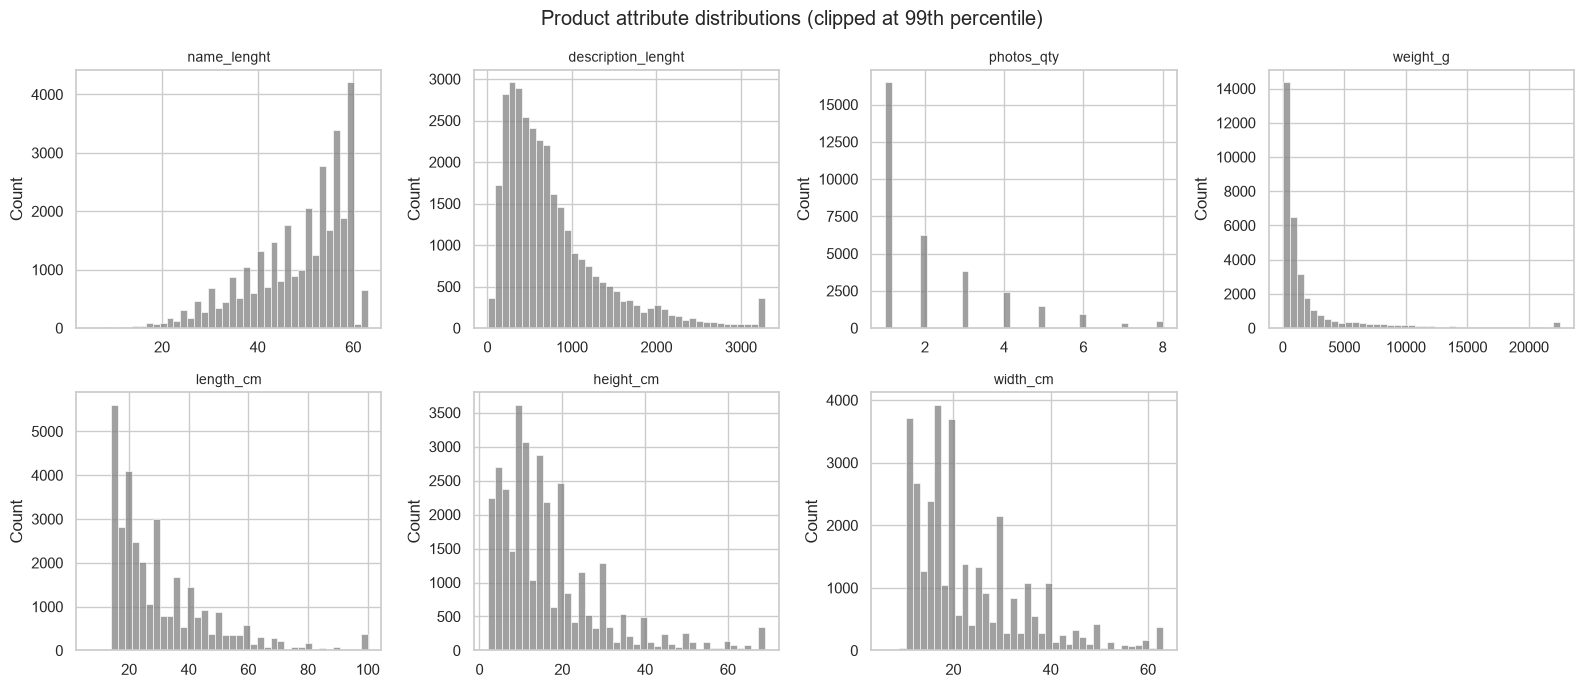

                               count     mean      std  min    25%    50%      75%       max
product_name_lenght        32,341.00    48.48    10.25 5.00  42.00  51.00    57.00     76.00
product_description_lenght 32,341.00   771.50   635.12 4.00 339.00 595.00   972.00  3,992.00
product_photos_qty         32,341.00     2.19     1.74 1.00   1.00   1.00     3.00     20.00
product_weight_g           32,949.00 2,276.47 4,282.04 0.00 300.00 700.00 1,900.00 40,425.00
product_length_cm          32,949.00    30.82    16.91 7.00  18.00  25.00    38.00    105.00
product_height_cm          32,949.00    16.94    13.64 2.00   8.00  13.00    21.00    105.00
product_width_cm           32,949.00    23.20    12.08 6.00  15.00  20.00    30.00    118.00


In [19]:
num_cols = ["product_name_lenght", "product_description_lenght", "product_photos_qty",
            "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols):
    s = products[c].dropna()
    sns.histplot(s.clip(upper=s.quantile(0.99)), bins=40, ax=ax, color="gray")
    ax.set_title(c.replace("product_", ""), fontsize=10); ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Product attribute distributions (clipped at 99th percentile)")
plt.tight_layout(); plt.show()

print(products[num_cols].describe().T)


### 3.4 Customers

In [20]:
overview(customers, 'customers')

=== customers: 99,441 rows x 5 cols ===


,dtype,non_null,null_%,n_unique,example
customer_id,str,99441,0.00,99441,06b8999e2fba1a1fbc88172c00ba8bc7
customer_unique_id,str,99441,0.00,96096,861eff4711a542e4b93843c6dd7febb0
customer_zip_code_prefix,int64,99441,0.00,14994,14409
customer_city,str,99441,0.00,4119,franca
customer_state,str,99441,0.00,27,SP


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


customer_id (one per order):        99,441
customer_unique_id (actual people):  96,096
Repeat customers (>1 order):        2,997 (3.1%)


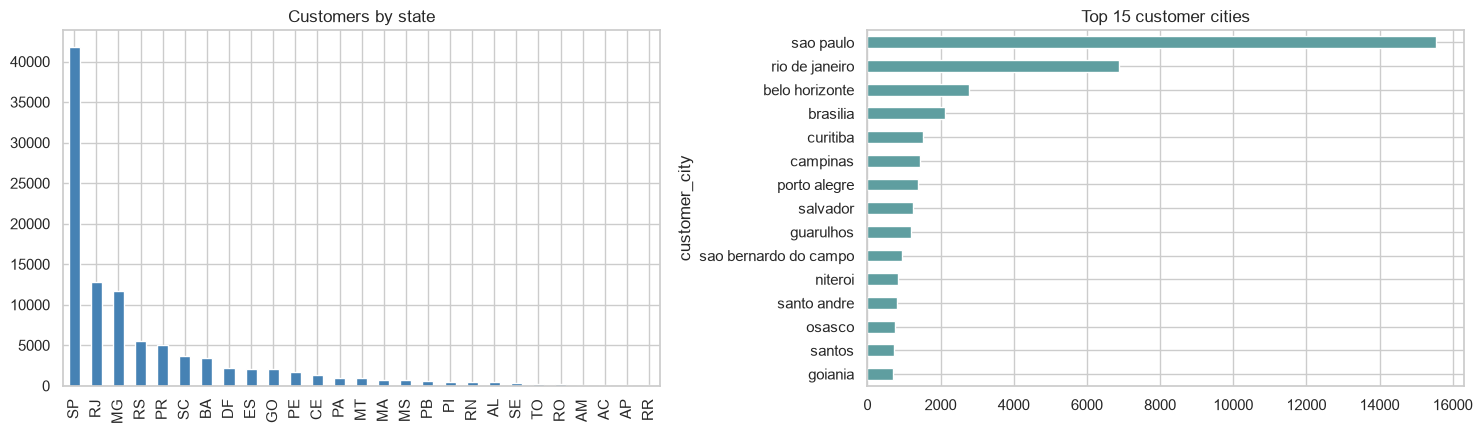

In [21]:
print(f"customer_id (one per order):        {customers.customer_id.nunique():,}")
print(f"customer_unique_id (actual people):  {customers.customer_unique_id.nunique():,}")
orders_per_person = customers.customer_unique_id.value_counts()
print(f"Repeat customers (>1 order):        {(orders_per_person > 1).sum():,} ({(orders_per_person > 1).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
customers.customer_state.value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Customers by state"); axes[0].set_xlabel("")

customers.customer_city.value_counts().head(15).plot.barh(ax=axes[1], color="cadetblue")
axes[1].invert_yaxis(); axes[1].set_title("Top 15 customer cities")
plt.tight_layout(); plt.show()


### 3.5 Sellers

In [22]:
overview(sellers, 'sellers')

=== sellers: 3,095 rows x 4 cols ===


,dtype,non_null,null_%,n_unique,example
seller_id,str,3095,0.00,3095,3442f8959a84dea7ee197c632cb2df15
seller_zip_code_prefix,int64,3095,0.00,2246,13023
seller_city,str,3095,0.00,611,campinas
seller_state,str,3095,0.00,23,SP


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


           count     mean       std  min    25%    50%      75%        max
orders  3,095.00    32.31    105.14 1.00   2.00   6.00    21.50   1,854.00
items   3,095.00    36.40    119.19 1.00   2.00   8.00    24.00   2,033.00
revenue 3,095.00 4,391.48 13,922.00 3.50 208.85 821.48 3,280.83 229,472.63


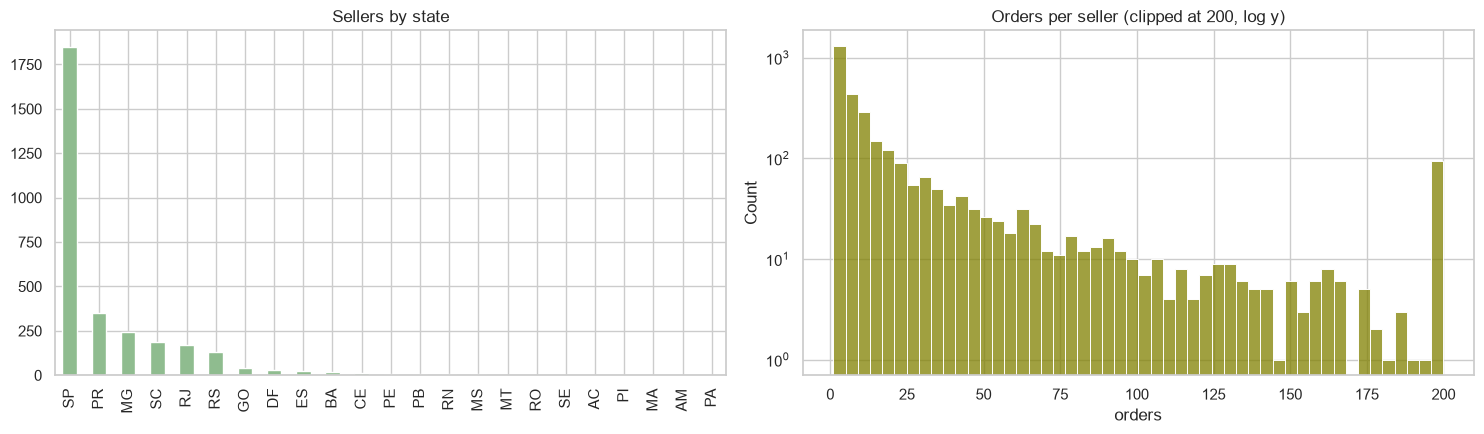

Top 10% of sellers generate 68% of item revenue


In [23]:
seller_stats = items.groupby("seller_id").agg(orders=("order_id", "nunique"),
                                              items=("order_item_id", "size"),
                                              revenue=("price", "sum"))
print(seller_stats.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sellers.seller_state.value_counts().plot.bar(ax=axes[0], color="darkseagreen")
axes[0].set_title("Sellers by state"); axes[0].set_xlabel("")

sns.histplot(seller_stats.orders.clip(upper=200), bins=50, ax=axes[1], color="olive")
axes[1].set_yscale("log"); axes[1].set_title("Orders per seller (clipped at 200, log y)")
plt.tight_layout(); plt.show()

share = seller_stats.revenue.sort_values(ascending=False).cumsum() / seller_stats.revenue.sum()
print(f"Top 10% of sellers generate {share.iloc[int(len(share)*0.1)]:.0%} of item revenue")


### 3.6 Payments

In [24]:
overview(payments, 'payments')

=== payments: 103,886 rows x 5 cols ===


,dtype,non_null,null_%,n_unique,example
order_id,str,103886,0.00,99440,b81ef226f3fe1789b1e8b2acac839d17
payment_sequential,int64,103886,0.00,29,1
payment_type,str,103886,0.00,5,credit_card
payment_installments,int64,103886,0.00,24,8
payment_value,float64,103886,0.00,29077,99.33


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


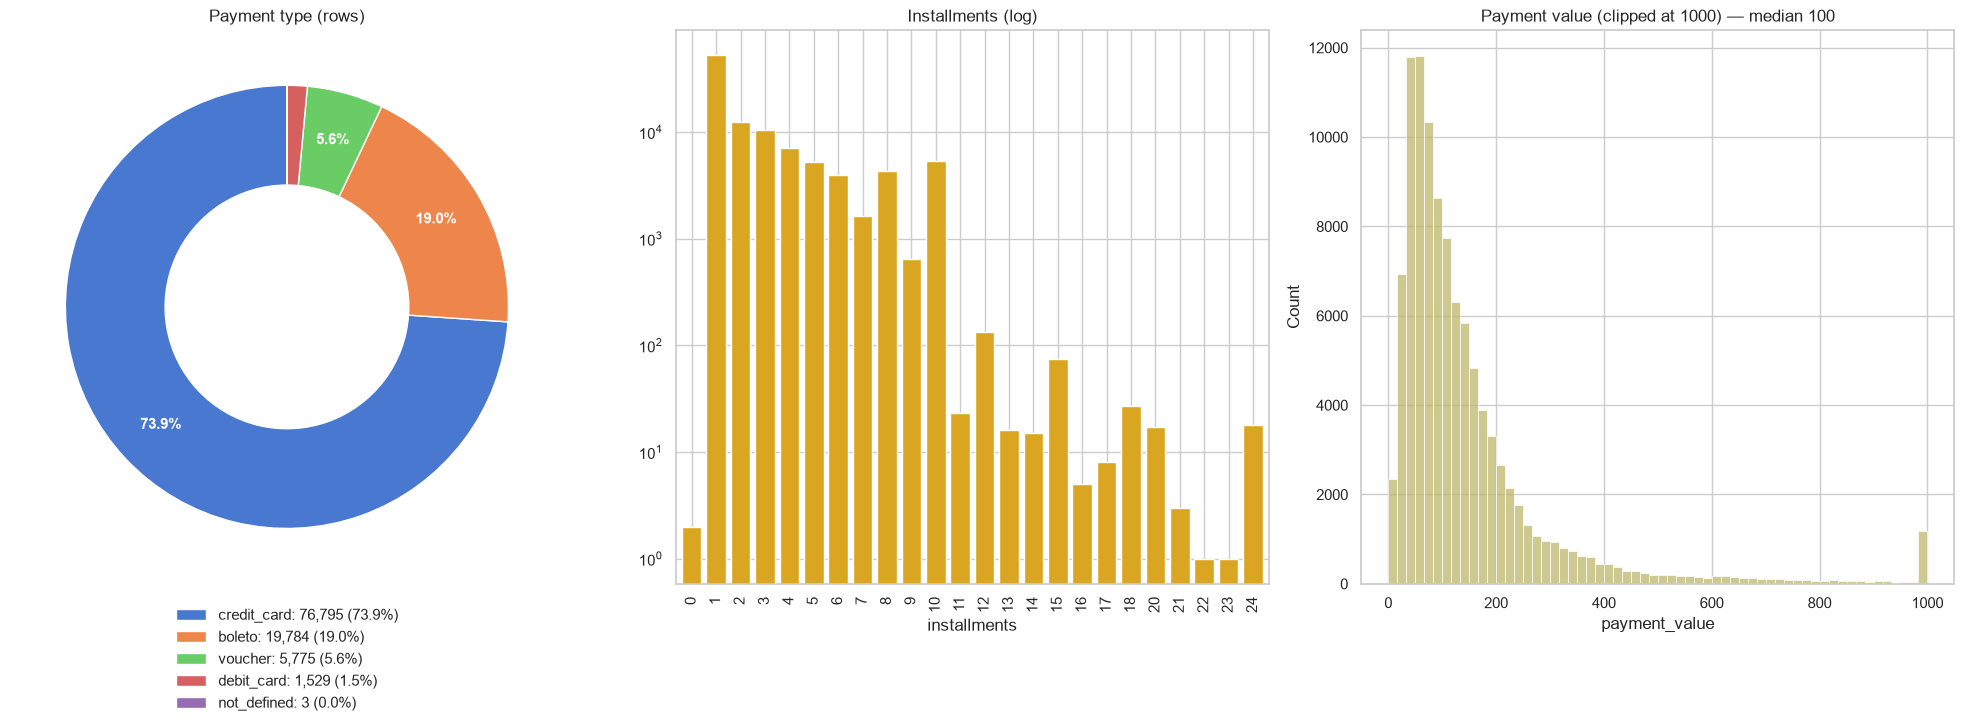

Orders with more than one payment record: 3,039 (3.1%)

Mean value & installments by payment type:
                  n  mean_value  mean_installments
payment_type                                      
boleto        19784      145.03               1.00
credit_card   76795      163.32               3.51
debit_card     1529      142.57               1.00
not_defined       3        0.00               1.00
voucher        5775       65.70               1.00


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

pt = payments.payment_type.value_counts()
share = pt / pt.sum()
wedges, *_ = axes[0].pie(
    pt, startangle=90, colors=sns.color_palette("muted"),
    wedgeprops=dict(width=0.45, edgecolor="white"),
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",     # skip labels on slivers
    pctdistance=0.78,
    textprops=dict(color="white", fontsize=11, weight="bold"),
)
axes[0].legend(wedges,
               [f"{k}: {v:,} ({s:.1%})" for k, v, s in zip(pt.index, pt, share)],
               loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=False)
axes[0].set_title("Payment type (rows)")

payments.payment_installments.value_counts().sort_index().plot.bar(ax=axes[1], color="goldenrod", width=0.8)
axes[1].set_yscale("log"); axes[1].set_title("Installments (log)"); axes[1].set_xlabel("installments")

sns.histplot(payments.payment_value.clip(upper=1000), bins=60, ax=axes[2], color="darkkhaki")
axes[2].set_title(f"Payment value (clipped at 1000) — median {payments.payment_value.median():.0f}")
plt.tight_layout(); plt.show()

multi = payments.groupby("order_id").payment_sequential.max()
print(f"Orders with more than one payment record: {(multi > 1).sum():,} ({(multi > 1).mean():.1%})")
print("\nMean value & installments by payment type:")
print(payments.groupby("payment_type").agg(n=("order_id", "size"),
                                            mean_value=("payment_value", "mean"),
                                            mean_installments=("payment_installments", "mean")))


### 3.7 Reviews

In [26]:
overview(reviews, 'reviews')

=== reviews: 99,224 rows x 7 cols ===


,dtype,non_null,null_%,n_unique,example
review_id,str,99224,0.00,98410,7bc2406110b926393aa56f80a40eba40
order_id,str,99224,0.00,98673,73fc7af87114b39712e6da79b0a377eb
review_score,int64,99224,0.00,5,4
review_comment_title,str,11568,88.34,4527,NaN
review_comment_message,str,40977,58.70,36159,NaN
review_creation_date,datetime64[us],99224,0.00,636,2018-01-18 00:00:00
review_answer_timestamp,datetime64[us],99224,0.00,98248,2018-01-18 21:46:59


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


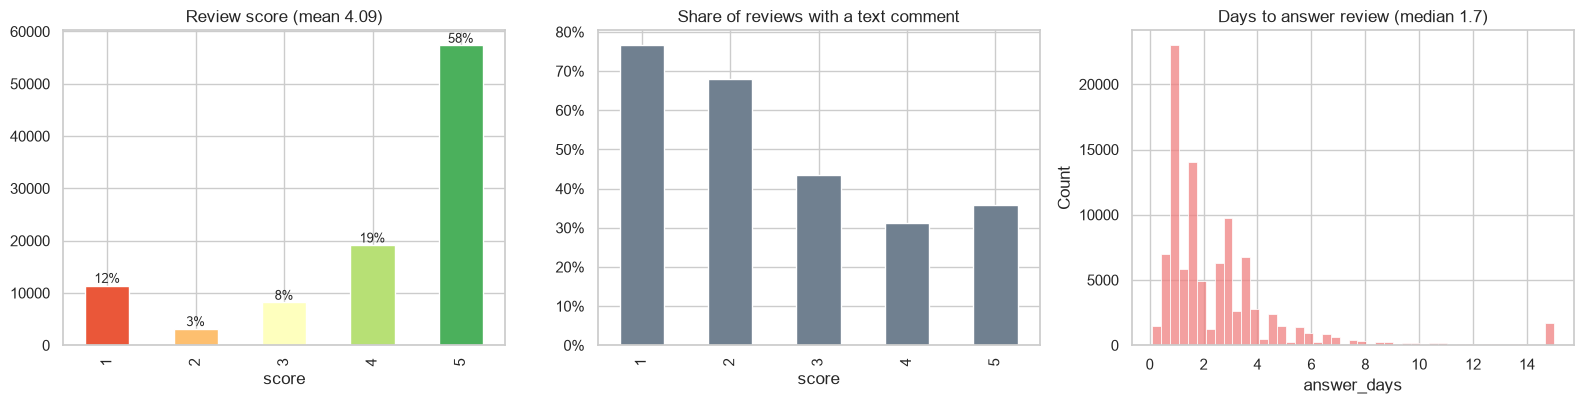

Unique review_id: 98,410 / 99,224 rows
Unique order_id:  98,673  -> some orders have multiple reviews, some review_ids cover multiple orders


In [27]:
reviews["has_title"] = reviews.review_comment_title.notna()
reviews["has_message"] = reviews.review_comment_message.notna()
reviews["answer_days"] = (reviews.review_answer_timestamp - reviews.review_creation_date).dt.total_seconds() / 86400

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sc = reviews.review_score.value_counts().sort_index()
sc.plot.bar(ax=axes[0], color=sns.color_palette("RdYlGn", 5))
axes[0].set_title(f"Review score (mean {reviews.review_score.mean():.2f})"); axes[0].set_xlabel("score")
for i, v in enumerate(sc):
    axes[0].text(i, v + 500, f"{v/sc.sum():.0%}", ha="center", fontsize=9)

reviews.groupby("review_score").has_message.mean().plot.bar(ax=axes[1], color="slategray")
axes[1].set_title("Share of reviews with a text comment"); axes[1].set_xlabel("score")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

sns.histplot(reviews.answer_days.clip(upper=15), bins=45, ax=axes[2], color="lightcoral")
axes[2].set_title(f"Days to answer review (median {reviews.answer_days.median():.1f})")
plt.tight_layout(); plt.show()

print(f"Unique review_id: {reviews.review_id.nunique():,} / {len(reviews):,} rows")
print(f"Unique order_id:  {reviews.order_id.nunique():,}  -> some orders have multiple reviews, some review_ids cover multiple orders")


### 3.8 Geolocation

In [28]:
overview(geo, 'geolocation')

=== geolocation: 1,000,163 rows x 5 cols ===


,dtype,non_null,null_%,n_unique,example
geolocation_zip_code_prefix,int64,1000163,0.00,19015,1037
geolocation_lat,float64,1000163,0.00,717360,-23.55
geolocation_lng,float64,1000163,0.00,717613,-46.64
geolocation_city,str,1000163,0.00,8011,sao paulo
geolocation_state,str,1000163,0.00,27,SP


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP


Rows: 1,000,163   unique zip prefixes: 19,015   exact duplicate rows: 261,831
Lat range: -36.61 to 45.07   Lng range: -101.47 to 121.11
Coordinates outside Brazil's bounding box: 42


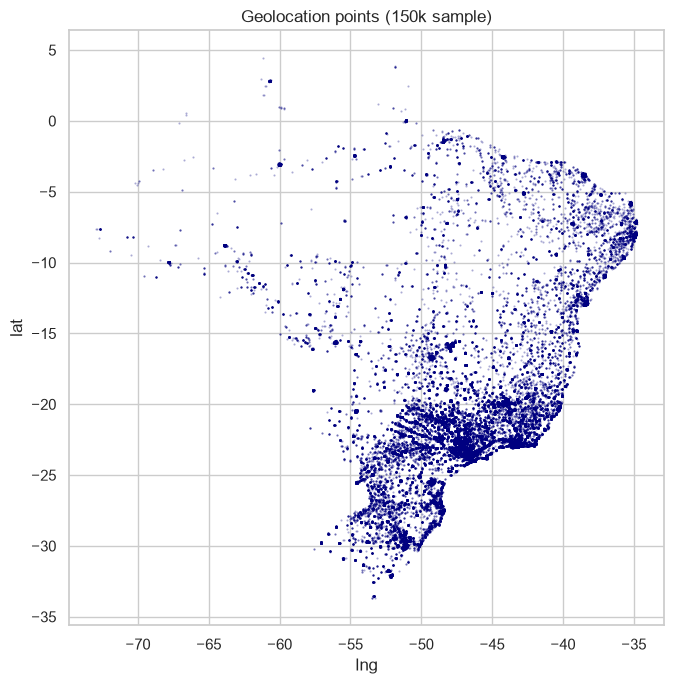

In [29]:
print(f"Rows: {len(geo):,}   unique zip prefixes: {geo.geolocation_zip_code_prefix.nunique():,}   exact duplicate rows: {geo.duplicated().sum():,}")
print(f"Lat range: {geo.geolocation_lat.min():.2f} to {geo.geolocation_lat.max():.2f}   Lng range: {geo.geolocation_lng.min():.2f} to {geo.geolocation_lng.max():.2f}")

# Brazil's bounding box (approx): lat -34 .. 6, lng -74 .. -34
in_br = geo.geolocation_lat.between(-34, 6) & geo.geolocation_lng.between(-74, -34)
print(f"Coordinates outside Brazil's bounding box: {(~in_br).sum():,}")

sample = geo[in_br].sample(150_000, random_state=0)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample.geolocation_lng, sample.geolocation_lat, s=0.3, alpha=0.3, c="navy")
ax.set_title("Geolocation points (150k sample)"); ax.set_xlabel("lng"); ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()


In [30]:
# One coordinate per zip prefix (median), used later for mapping customers & sellers
geo_zip = (geo[in_br].groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
           .median().rename(columns={"geolocation_lat": "lat", "geolocation_lng": "lng"}))
print(f"Zip prefixes with coordinates: {len(geo_zip):,}")
print(f"Customer zips covered: {customers.customer_zip_code_prefix.isin(geo_zip.index).mean():.1%}")
print(f"Seller zips covered:   {sellers.seller_zip_code_prefix.isin(geo_zip.index).mean():.1%}")


Zip prefixes with coordinates: 19,010
Customer zips covered: 99.7%
Seller zips covered:   99.8%


### 3.9 Category name translation

In [31]:
overview(cat_tr, 'category_translation', n=5)
print("Translations never used by any product:",
      sorted(set(cat_tr.product_category_name) - set(products.product_category_name.dropna())))


=== category_translation: 71 rows x 2 cols ===


,dtype,non_null,null_%,n_unique,example
product_category_name,str,71,0.00,71,beleza_saude
product_category_name_english,str,71,0.00,71,health_beauty


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translations never used by any product: []


## 4. How the tables link together

In [32]:
def check(label, child, child_key, parent, parent_key):
    matched = child[child_key].isin(parent[parent_key])
    return {"relationship": label, "child_rows": len(child), "matched_%": 100 * matched.mean(),
            "orphans": int((~matched).sum())}

checks = pd.DataFrame([
    check("orders.customer_id -> customers",      orders,   "customer_id", customers, "customer_id"),
    check("order_items.order_id -> orders",       items,    "order_id",    orders,    "order_id"),
    check("order_items.product_id -> products",   items,    "product_id",  products,  "product_id"),
    check("order_items.seller_id -> sellers",     items,    "seller_id",   sellers,   "seller_id"),
    check("payments.order_id -> orders",          payments, "order_id",    orders,    "order_id"),
    check("reviews.order_id -> orders",           reviews,  "order_id",    orders,    "order_id"),
    check("products.category -> translation",    products.dropna(subset=["product_category_name"]),
                                                            "product_category_name", cat_tr, "product_category_name"),
    check("customers.zip -> geolocation",         customers, "customer_zip_code_prefix", geo, "geolocation_zip_code_prefix"),
    check("sellers.zip -> geolocation",           sellers,   "seller_zip_code_prefix",   geo, "geolocation_zip_code_prefix"),
]).set_index("relationship")

checks["matched_%"] = checks["matched_%"].round(2)
checks

,child_rows,matched_%,orphans
relationship,,,
orders.customer_id -> customers,99441,100.00,0
order_items.order_id -> orders,112650,100.00,0
order_items.product_id -> products,112650,100.00,0
order_items.seller_id -> sellers,112650,100.00,0
payments.order_id -> orders,103886,100.00,0
reviews.order_id -> orders,99224,100.00,0
products.category -> translation,32341,99.96,13
customers.zip -> geolocation,99441,99.72,278
sellers.zip -> geolocation,3095,99.77,7


In [33]:
# Coverage the other way round: which orders lack items / payments / reviews?
cov = pd.DataFrame({
    "has_items":    orders.order_id.isin(items.order_id).values,
    "has_payment":  orders.order_id.isin(payments.order_id).values,
    "has_review":   orders.order_id.isin(reviews.order_id).values,
}, index=orders.order_id)
print((100 * cov.mean()).round(2).rename("% of orders"))
print("\nOrders without items, by status:")
print(orders[~cov.has_items.values].order_status.value_counts())


has_items      99.22
has_payment   100.00
has_review     99.23
Name: % of orders, dtype: float64

Orders without items, by status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


The 775 items

In [48]:
# ---- Orders with no line items (excluded from the consolidated dataset) ----
no_items = orders[~orders.order_id.isin(items.order_id)].copy()
print(f"{len(no_items):,} orders have no rows in order_items  "
      f"({orders.order_id.nunique():,} - {len(no_items)} = {items.order_id.nunique():,} in the consolidated dataset)")

print("\nStatus:")
print(no_items.order_status.value_counts())

print("\nHow far each got through the pipeline (% with timestamp):")
print((100 * no_items[["order_approved_at", "order_delivered_carrier_date",
                       "order_delivered_customer_date"]].notna().mean()).round(1))

# Payments and reviews attached to them
ni_pay = payments[payments.order_id.isin(no_items.order_id)]
ni_rev = reviews[reviews.order_id.isin(no_items.order_id)]
print(f"\nWith a payment record: {no_items.order_id.isin(payments.order_id).mean():.1%}   "
      f"total paid: R$ {ni_pay.payment_value.sum():,.0f}   median: R$ {ni_pay.payment_value.median():.2f}")
print(f"With a review:         {no_items.order_id.isin(reviews.order_id).mean():.1%}   "
      f"mean score: {ni_rev.review_score.mean():.2f}  (all orders: {reviews.review_score.mean():.2f})")
print("Score distribution:", ni_rev.review_score.value_counts().sort_index().to_dict())

775 orders have no rows in order_items  (99,441 - 775 = 98,666 in the consolidated dataset)

Status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

How far each got through the pipeline (% with timestamp):
order_approved_at               81.20
order_delivered_carrier_date     0.10
order_delivered_customer_date    0.00
dtype: float64

With a payment record: 100.0%   total paid: R$ 162,592   median: R$ 98.22
With a review:         97.5%   mean score: 1.73  (all orders: 4.09)
Score distribution: {1: 540, 2: 62, 3: 53, 4: 33, 5: 71}


In [47]:
no_items_detail = (no_items[["order_id", "order_status", "order_purchase_timestamp", "order_approved_at"]]
    .merge(ni_pay.groupby("order_id").agg(payment_type=("payment_type", "first"),
                                          paid=("payment_value", "sum")), on="order_id", how="left")
    .merge(ni_rev[["order_id", "review_score", "review_comment_message"]], on="order_id", how="left")
    .sort_values("order_purchase_timestamp"))

pd.set_option("display.max_colwidth", 120)
no_items_detail                     # all 775 rows (778 after the review join — a few orders have 2 reviews)

,order_id,order_status,order_purchase_timestamp,order_approved_at,payment_type,paid,review_score,review_comment_message
77,809a282bbd5dbcabb6f2f724fca862ec,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,credit_card,40.95,1.00,MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NENHUMA SATISTAÇÃO
600,1aecadf4362edaca7fa033e882076c8d,canceled,2016-10-04 10:05:45,2016-10-04 10:26:40,credit_card,50.74,2.00,NaN
604,620b0acb9258b51defbc51804c5298d5,canceled,2016-10-04 11:44:01,2016-10-05 08:45:09,credit_card,451.44,1.00,"NÃO ENVIARAM O PRODUTO E NINGUÉM ME DEU JUSTIFICATIVA, NEM PREVISÃO E NO SITE DO stark ESTAVA CONSTANDO COMO ENVIADO..."
18,ddaec6fff982b13e7e048b627a11d6da,canceled,2016-10-04 19:41:32,NaT,boleto,116.99,1.00,"Nunca chegou o produto, deram uma excusa e trocaram o valor porcum vale."
180,a68ce1686d536ca72bd2dadc4b8671e5,shipped,2016-10-05 01:47:40,2016-10-07 03:11:22,boleto,77.73,1.00,Comprei o produto dia 06/10/2016 hj é 15/12/2016 SENDO QUE ERA 38 DIAS DE ENTREGA JÁ FAZEM MAIS DE 60 DIAS E NADA NÃ...
...,...,...,...,...,...,...,...,...
395,392ed9afd714e3c74767d0c4d3e3f477,canceled,2018-09-29 09:13:03,NaT,voucher,137.03,1.00,o produto foi entregue errado eu estou esperado contatos da loja para resolver a situação\r\n
696,616fa7d4871b87832197b2a137a115d2,canceled,2018-10-01 15:30:09,NaT,voucher,80.38,2.00,NaN
247,a2ac6dad85cf8af5b0afb510a240fe8c,canceled,2018-10-03 18:55:29,NaT,voucher,197.55,1.00,quero devolver o produto comprei um veio outro;;;\r\nquero meu dinheiro de volta.
524,b059ee4de278302d550a3035c4cdb740,canceled,2018-10-16 20:16:02,NaT,voucher,222.03,5.00,Os produtos são de boa qualidade e o preço que adquiri foi excelente.


## 5. Cross-table analysis

In [34]:
# Build one analytical frame at order-item grain
df = (items
      .merge(products_en[["product_id", "category", "product_weight_g"]], on="product_id", how="left")
      .merge(orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp",
                     "order_delivered_customer_date", "order_estimated_delivery_date"]], on="order_id", how="left")
      .merge(customers[["customer_id", "customer_unique_id", "customer_state", "customer_city"]], on="customer_id", how="left")
      .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left"))

df["category"]      = df["category"].fillna("unknown")
df["year_month"]    = df.order_purchase_timestamp.dt.to_period("M")
df["day_of_week"]   = df.order_purchase_timestamp.dt.day_name()
df["delivery_days"] = (df.order_delivered_customer_date - df.order_purchase_timestamp).dt.days
df["is_on_time"]    = df.order_delivered_customer_date <= df.order_estimated_delivery_date   # False when undelivered
df["item_revenue"]  = df.price + df.freight_value

full = df   # keep the old name so the rest of Section 5 runs unchanged

n_dropped = orders.order_id.nunique() - df.order_id.nunique()
print(f"{len(df):,} line items across {df.order_id.nunique():,} orders "
      f"({n_dropped} orders had no items and are excluded — see Section 4)")

112,650 line items across 98,666 orders (775 orders had no items and are excluded — see Section 4)


In [35]:
order_totals = df.groupby("order_id").price.sum()
delivered_df = df[df.order_status == "delivered"]
orders_per_person = customers.customer_unique_id.value_counts()

kpis = pd.Series({
    "Orders (with items)":     f"{df.order_id.nunique():,}",
    "Unique customers":        f"{customers.customer_unique_id.nunique():,}",
    "Item revenue (R$)":       f"{df.price.sum():,.0f}",
    "Revenue incl. freight":   f"{df.item_revenue.sum():,.0f}",
    "AOV mean / median (R$)":  f"{order_totals.mean():.2f} / {order_totals.median():.2f}",
    "Repeat rate":             f"{(orders_per_person > 1).mean():.1%}",
    "Median delivery days":    f"{delivered_df.drop_duplicates('order_id').delivery_days.median():.0f}",
    "On-time delivery":        f"{delivered_df.drop_duplicates('order_id').is_on_time.mean():.1%}",
    "Avg review score":        f"{reviews.review_score.mean():.2f}",
}, name="value")
kpis.to_frame()

,value
Orders (with items),"98,666"
Unique customers,"96,096"
Item revenue (R$),"13,591,644"
Revenue incl. freight,"15,843,553"
AOV mean / median (R$),137.75 / 86.90
Repeat rate,3.1%
Median delivery days,10
On-time delivery,91.9%
Avg review score,4.09


### 5.1 Revenue

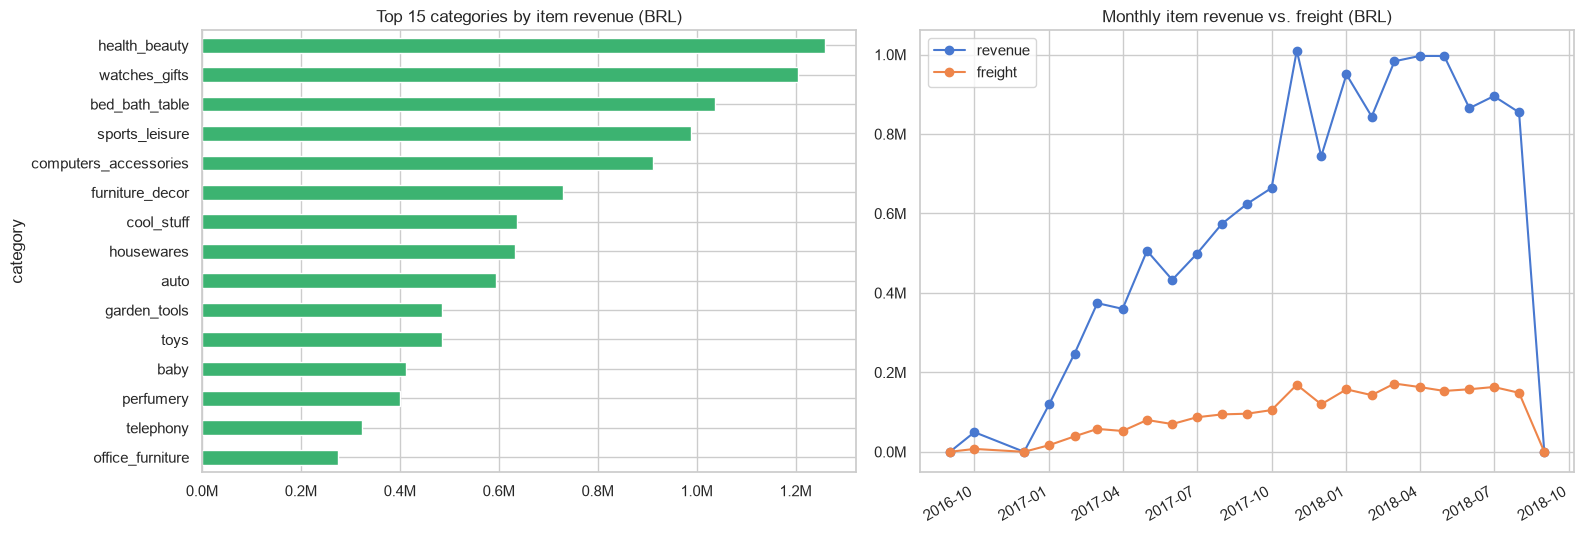

Total item revenue: R$ 13,591,644   total freight: R$ 2,251,910


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

rev_cat = full.groupby("category").price.sum().sort_values(ascending=False).head(15)
rev_cat.plot.barh(ax=axes[0], color="mediumseagreen")
axes[0].invert_yaxis(); axes[0].set_title("Top 15 categories by item revenue (BRL)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

rev_m = full.groupby("year_month").agg(revenue=("price", "sum"), freight=("freight_value", "sum"))
rev_m.index = rev_m.index.to_timestamp()
rev_m.plot(ax=axes[1], marker="o")
axes[1].set_title("Monthly item revenue vs. freight (BRL)"); axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()

print(f"Total item revenue: R$ {full.price.sum():,.0f}   total freight: R$ {full.freight_value.sum():,.0f}")


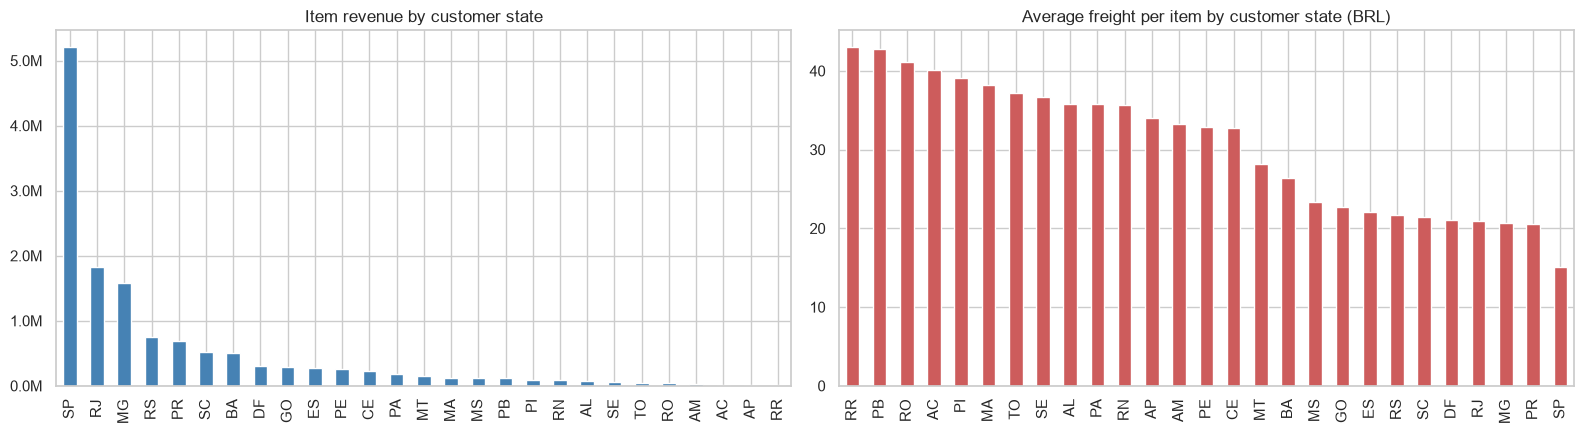

,orders,revenue,avg_freight,revenue_per_order
customer_state,,,,
SP,41375,"5,202,955.05",15.15,125.75
RJ,12762,"1,824,092.67",20.96,142.93
MG,11544,"1,585,308.03",20.63,137.33
RS,5432,"750,304.02",21.74,138.13
PR,4998,"683,083.76",20.53,136.67
SC,3612,"520,553.34",21.47,144.12
BA,3358,"511,349.99",26.36,152.28
DF,2125,"302,603.94",21.04,142.40
GO,2007,"294,591.95",22.77,146.78


In [39]:
state = full.groupby("customer_state").agg(orders=("order_id", "nunique"),
                                            revenue=("price", "sum"),
                                            avg_freight=("freight_value", "mean"))
state["revenue_per_order"] = state.revenue / state.orders
state = state.sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
state.revenue.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Item revenue by customer state"); axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

state.avg_freight.sort_values(ascending=False).plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("Average freight per item by customer state (BRL)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()
state.head(10)


### 5.2 Delivery and reviews

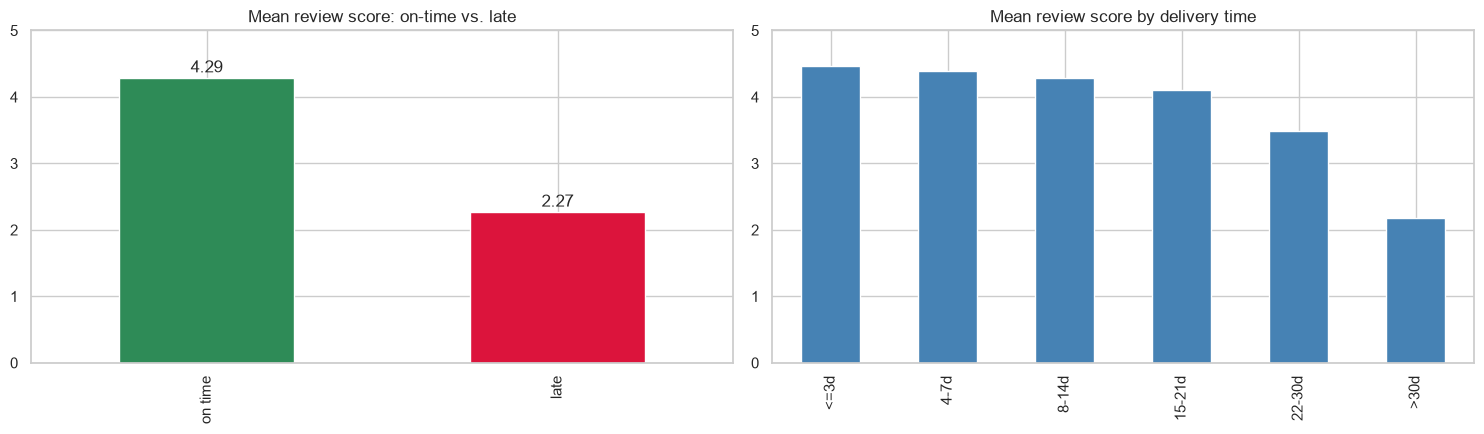

review_score    1    2    3    4    5
is_late                              
on time      0.07 0.03 0.08 0.20 0.62
late         0.54 0.09 0.11 0.10 0.17


In [40]:
# One review score per order (latest review), joined to delivery outcome
rev_order = reviews.sort_values("review_creation_date").drop_duplicates("order_id", keep="last")[["order_id", "review_score"]]
dr = delivered.merge(rev_order, on="order_id", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
dr.groupby("is_late").review_score.mean().rename({False: "on time", True: "late"}).plot.bar(ax=axes[0], color=["seagreen", "crimson"])
axes[0].set_title("Mean review score: on-time vs. late"); axes[0].set_ylim(0, 5); axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 0.08, f"{p.get_height():.2f}", ha="center")

dr["delivery_bucket"] = pd.cut(dr.delivery_days, [-1, 3, 7, 14, 21, 30, 1000],
                               labels=["<=3d", "4-7d", "8-14d", "15-21d", "22-30d", ">30d"])
dr.groupby("delivery_bucket").review_score.mean().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("Mean review score by delivery time"); axes[1].set_ylim(0, 5); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

print(pd.crosstab(dr.is_late, dr.review_score, normalize="index").round(3).rename(index={False: "on time", True: "late"}))


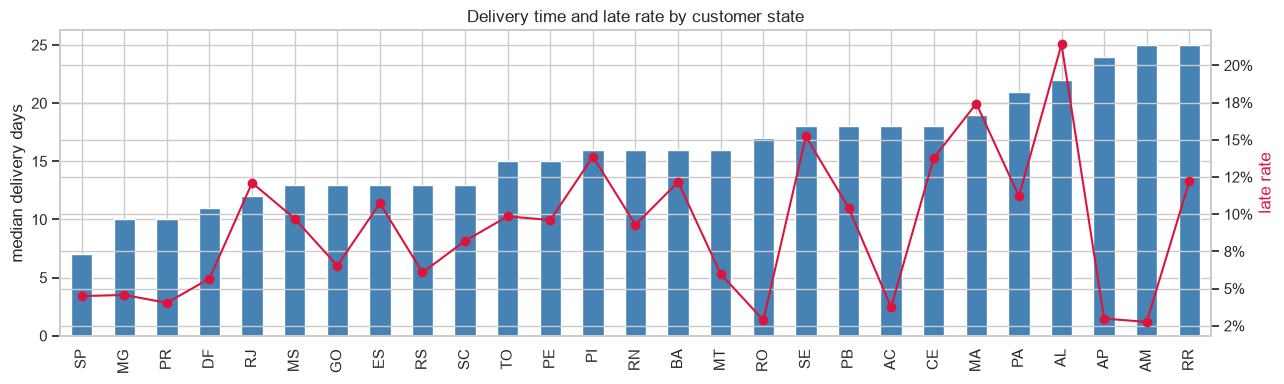

In [41]:
# Delivery time by customer state
dstate = (delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id")
          .groupby("customer_state").agg(median_days=("delivery_days", "median"), late_rate=("is_late", "mean"), n=("order_id", "size"))
          .sort_values("median_days"))
fig, ax = plt.subplots(figsize=(13, 4))
dstate.median_days.plot.bar(ax=ax, color="steelblue")
ax2 = ax.twinx()
dstate.late_rate.plot(ax=ax2, marker="o", color="crimson", lw=1.5)
ax.set_ylabel("median delivery days"); ax2.set_ylabel("late rate", color="crimson")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Delivery time and late rate by customer state"); ax.set_xlabel("")
plt.tight_layout(); plt.show()


### 5.3 Where customers and sellers are

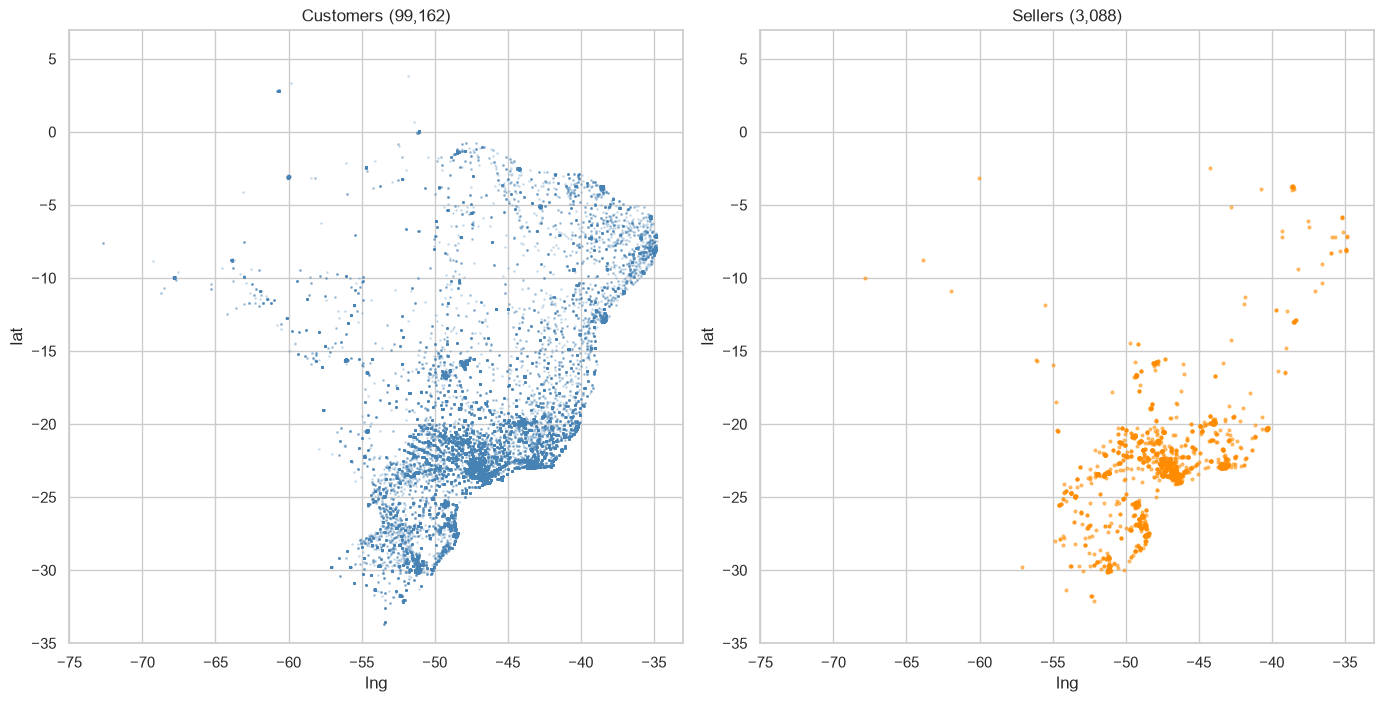

Items shipped within the same state: 36.2%
Items shipped from SP sellers: 71.3%


In [42]:
cust_pts = customers.merge(geo_zip, left_on="customer_zip_code_prefix", right_index=True)
sell_pts = sellers.merge(geo_zip, left_on="seller_zip_code_prefix", right_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].scatter(cust_pts.lng, cust_pts.lat, s=1, alpha=0.2, c="steelblue")
axes[0].set_title(f"Customers ({len(cust_pts):,})")
axes[1].scatter(sell_pts.lng, sell_pts.lat, s=4, alpha=0.5, c="darkorange")
axes[1].set_title(f"Sellers ({len(sell_pts):,})")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("lng"); ax.set_ylabel("lat")
    ax.set_xlim(-75, -33); ax.set_ylim(-35, 7)
plt.tight_layout(); plt.show()

same_state = (full.customer_state == full.seller_state).mean()
print(f"Items shipped within the same state: {same_state:.1%}")
print(f"Items shipped from SP sellers: {(full.seller_state == 'SP').mean():.1%}")


In [43]:
df.to_csv(DATA_DIR + "smartcommerce_consolidated.csv", index=False)

## 6. Key takeaways

**Data quality**
- The nine tables join cleanly on `order_id`, `customer_id`, `product_id` and `seller_id` — effectively zero orphan keys. The only soft link is zip prefix → geolocation, where a small share of prefixes has no coordinates.
- `customer_id` is one-per-order; use `customer_unique_id` to identify people. Repeat buying is rare (~3%).
- `geolocation` holds raw coordinate observations (with duplicates and a few points outside Brazil); aggregate to one point per zip prefix before joining.
- `review_id` is not unique and some orders carry multiple reviews — deduplicate before joining to orders.
- Product category names are Portuguese; the translation table covers all but two categories, and ~2% of products have no category at all.

**Business picture**
- ~99k orders, Sep 2016 → Aug 2018, ~97% delivered. Volume grows steadily through 2017, peaks around Nov 2017 (Black Friday) and plateaus in 2018.
- Purchases cluster on weekdays and in the afternoon/evening; Saturdays and Sundays are the quietest days.
- Most orders contain a single item; item prices are heavily right-skewed (median ≈ R$75). Freight is a meaningful share of price, and is highest for the North/Northeast states far from the São Paulo seller base.
- Credit card dominates payments (~74%), with boleto second; multi-installment plans are common.
- Reviews skew positive (mean ≈ 4.1, >55% five-star), but score drops sharply with delivery delay: late orders average roughly 2 points lower than on-time ones. Delivery time is the single strongest lever visible in the data.
- Median delivery is about 10 days, with ~7% of deliveries arriving after the estimated date; the late rate spikes in early 2018.
- Sellers are concentrated in São Paulo state, and a small share of sellers accounts for most revenue.
